# Playground
Aca podemos cargar sesiones, ver los mapas y ajustar parametros.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from core.data_loader import load_session
from core.place_fields import draw_neuron_analysis, compute_rate_map

# parametros
animal = "R004"
session_file = "2026_06_17_merged.mat"
neuron_idx = 0

In [5]:
# 1. cargar datos
data = load_session(animal, session_file)
x = data['x']
y = data['y']
v = data['v']
t = data['t']
spikes = data['S'][:, neuron_idx]
print(f"Cargada sesión {animal}/{session_file}. Neurona {neuron_idx}: {np.sum(spikes > 0)} eventos de disparo.")

Cargada sesión R004/2026_06_17_merged.mat. Neurona 0: 2020 eventos de disparo.


In [ ]:
# 2. calcular Place Field
rate_map, x_bins, y_bins = compute_rate_map(
    x, y, t, spikes,
    bin_size=2.5,  # tamaño del bin en cm
    sigma=2.5,     # radio de suavizado gaussiano del place field
)
extent = [x_bins[0], x_bins[-1], y_bins[0], y_bins[-1]]

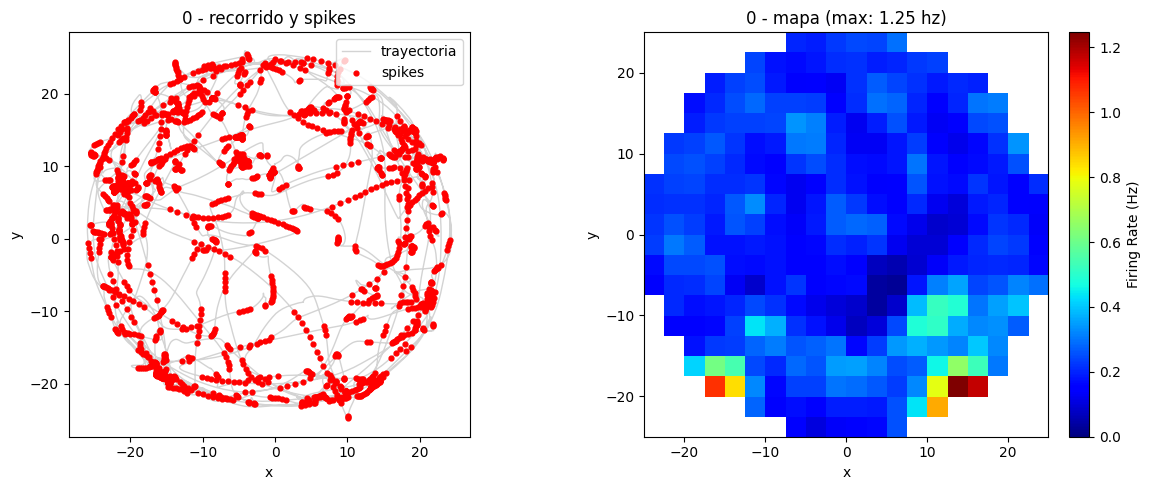

In [21]:
# 3. Graficar
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Nota sobre la trayectoria:
# La función dibuja 'x' e 'y' DIRECTAMENTE como vienen del .mat. 
# No hay ningún suavizado extra sobre la línea de trayectoria.
im = draw_neuron_analysis(ax1, ax2, x, y, spikes, rate_map, extent, neuron_id=neuron_idx)

cbar = fig.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
cbar.set_label("Firing Rate (Hz)")
plt.tight_layout()
plt.show()